# 3D cutaway comparison

Render one MRI case with the reference mask and three model predictions. Single-frame previews are checked before the four rotation sequences are rendered.

In [ ]:
from pathlib import Path
import os
import sys
from functools import partial

_start = Path(os.environ.get("BRATS_PROJECT_ROOT", Path.cwd())).expanduser().resolve()
PROJECT_ROOT = next(
    (p for p in (_start, *_start.parents) if (p / "src" / "brats_pipeline").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Place notebooks/ and src/ under one project root, or set BRATS_PROJECT_ROOT.")
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
from brats_pipeline.common import ProjectPaths
paths_io = ProjectPaths(PROJECT_ROOT)
resolve_existing_path = paths_io.resolve
print("Project:", PROJECT_ROOT)

In [2]:
import json
import copy
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, Video, display
from brats_pipeline.common import (
    array_digest, file_digest, signature, save_json,
    load_array_cache, save_array_cache,
)
from brats_pipeline.data import (
    load_nii, normalize_nonzero, canonicalize_brats_labels,
    validate_label_values, select_manifest_row, jp, xyz_to_dhw,
    xyz_to_dhw_seg, dhw_to_xyz,
)
from brats_pipeline.inference import (
    create_segresnet, load_trusted_checkpoint, extract_model_state_dict,
    predict_probs_dhw, make_pred_with_et_threshold, make_metric_row,
)
from brats_pipeline.rendering import (
    BrainManualCut3D, save_cutaway_frame, render_cutaway_video, frames_to_mp4,
    DEFAULT_REGION_NAMES,
)

/home/mandrakedrink/miniforge3/envs/research_dt_bs/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Case, models and output settings

In [ ]:
PATIENT_ID = "BraTS2021_00269"

MODEL_KWARGS = {
    "spatial_dims": 3,
    "in_channels": 4,
    "out_channels": 4,
    "init_filters": 32,
    "blocks_down": (1, 2, 2, 4),
    "blocks_up": (1, 1, 1),
    "dropout_prob": 0.1,
}

MODEL_CONFIGS = {
    "Centralized S32": {
        "checkpoint": "models/centralized_segresnet32_final/segresnet_final_best_mean_dice.pt",
        "et_threshold": 0.5,
        "title": "BraTS | Centralized S32 Prediction",
        "folder": "02_centralized_s32",
        "video_name": "centralized_s32.mp4",
    },
    "FedAvg S32": {
        "checkpoint": "models/federated_fedavg_segresnet32_final/fedavg_best_mean_dice.pt",
        "et_threshold": 0.5,
        "title": "BraTS | FedAvg S32 Prediction",
        "folder": "03_fedavg_s32",
        "video_name": "fedavg_s32.mp4",
    },
    "FedProx S32": {
        "checkpoint": "models/federated_fedprox_segresnet32_final/fedprox_best_mean_dice.pt",
        "et_threshold": 0.5,
        "title": "BraTS | FedProx S32 Prediction",
        "folder": "04_fedprox_s32",
        "video_name": "fedprox_s32.mp4",
    },
}

GT_TITLE = "BraTS | Ground Truth 3D Tumor Regions"

# Retained XYZ range for the selected case.
CUT = (
    slice(None, 145),  # X: :145
    slice(None, 200),  # Y: :200
    slice(None, 110),
)
SIDES = ("low", "low", "low")

# Preview frame angle.
ANGLE_PREVIEW = 35
ELEV = 25

# Full circle video. 355 avoids duplicating the 0-degree frame.
ANGLE_START = 0
ANGLE_END = 355
ANGLE_STEP = 5

FPS = 12
DPI = 140

# Legend positions for rotation previews and final renders.
LEGEND_POSITION = "bottom_left"

FORCE_RERENDER_FRAMES = False
USE_CACHED_PREDICTIONS = True
RENDER_VIDEOS = False

MANIFEST_PATH = PROJECT_ROOT / "data/processed/manifest_4clients_seed42.csv"
FIGURES_DIR = PROJECT_ROOT / "docs/figures"
OUTPUT_ROOT = FIGURES_DIR / "brats_3d_cutaway_video"
PRED_DIR = OUTPUT_ROOT / "saved_predictions"

VIZ_OPTIONS = dict(
    resize_volume=False, crop_bg=False,
    title_fontsize=28, legend_fontsize=18, title_pad=22,
    subplot_adjust=(0.00, 1.00, 0.03, 0.80),
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Patient:", PATIENT_ID)
print("Device:", device)

## Load and check the selected case

In [13]:
manifest = pd.read_csv(MANIFEST_PATH)
row = select_manifest_row(manifest, PATIENT_ID)
case_paths = jp(row["paths"])
volumes = {
    name: load_nii(case_paths[name], project_root=PROJECT_ROOT)
    for name in ("t1", "t1ce", "t2", "flair", "seg")
}
if len({volume.shape for volume in volumes.values()}) != 1:
    raise ValueError("The five arrays do not share one XYZ shape.")
validate_label_values(volumes["seg"])
t1, t1ce, t2, flair = (volumes[name] for name in ("t1", "t1ce", "t2", "flair"))
seg = canonicalize_brats_labels(volumes["seg"])
image_xyz_for_model = np.stack([
    normalize_nonzero(volumes[name]) for name in ("t1", "t1ce", "t2", "flair")
]).astype(np.float32)
image_dhw_for_model = xyz_to_dhw(image_xyz_for_model)
gt_dhw = xyz_to_dhw_seg(seg)
title = f"{PATIENT_ID}_{row['client_domain']}_{row['split']}"
id_ = PATIENT_ID.replace("BraTS2021_", "")
safe_title = BrainManualCut3D.safe_filename(title)
input_digest = array_digest(image_dhw_for_model)
print("MRI XYZ:", flair.shape)
print("Model CDHW:", image_dhw_for_model.shape)
print("Labels:", np.unique(seg))
print("Source domain / split:", row["client_domain"], row["split"])
print("Region counts:", {"WT": int((seg > 0).sum()),
                        "TC": int(np.isin(seg, [1, 3]).sum()),
                        "ET": int((seg == 3).sum())})
# Nested-mask identities are automatic with these definitions; they do not prove registration.

MRI XYZ: (240, 240, 155)
Model CDHW: (4, 155, 240, 240)
Labels: [0 1 2 3]
Source domain / split: UPENN-GBM train
Region counts: {'WT': 96630, 'TC': 31083, 'ET': 25471}


## Frozen-checkpoint predictions and per-case metrics

Prediction caches are keyed by the case input, checkpoint content, inference settings, and ET threshold. The legend is computed from the mask displayed in each panel.

In [15]:
raw_preds = {}
thresholded_preds = {}
raw_rows = []
thresholded_rows = []
checkpoint_hashes = {}

for model_name, cfg in MODEL_CONFIGS.items():
    checkpoint_path = resolve_existing_path(cfg["checkpoint"], label=model_name)
    checkpoint_hashes[model_name] = file_digest(checkpoint_path)
    payload = {
        "patient_id": PATIENT_ID, "input_dhw_sha256": input_digest,
        "checkpoint_sha256": checkpoint_hashes[model_name],
        "model_kwargs": MODEL_KWARGS,
        "roi_size": [128, 128, 128], "overlap": 0.5, "sw_batch_size": 1,
        "mode": "gaussian", "use_amp": device.type == "cuda",
        "et_threshold": cfg["et_threshold"],
        "threshold_rule": "best_non_ET_then_p_ET_ge_threshold",
    }
    cache_dir = PRED_DIR / safe_title / BrainManualCut3D.safe_filename(model_name)
    cached = load_array_cache(
        cache_dir,
        payload,
        ["raw_xyz", "thresholded_xyz"]
    ) if USE_CACHED_PREDICTIONS else None
    if cached is None:
        print("Inference:", model_name)
        model = create_segresnet(MODEL_KWARGS).to(device)
        checkpoint = load_trusted_checkpoint(checkpoint_path)
        model.load_state_dict(extract_model_state_dict(checkpoint), strict=True)
        probabilities = predict_probs_dhw(model, image_dhw_for_model, device)
        raw_xyz = dhw_to_xyz(np.argmax(probabilities, axis=0).astype(np.uint8))
        thresholded_xyz = dhw_to_xyz(make_pred_with_et_threshold(probabilities, cfg["et_threshold"]))
        save_array_cache(cache_dir, payload, {"raw_xyz": raw_xyz, "thresholded_xyz": thresholded_xyz})
        del model, checkpoint, probabilities
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    else:
        print("Cached:", model_name)
        raw_xyz, thresholded_xyz = cached["raw_xyz"], cached["thresholded_xyz"]
    if raw_xyz.shape != seg.shape or thresholded_xyz.shape != seg.shape:
        raise ValueError("Prediction geometry differs from the selected ground truth.")
    validate_label_values(raw_xyz)
    validate_label_values(thresholded_xyz)
    raw_preds[model_name] = raw_xyz
    thresholded_preds[model_name] = thresholded_xyz
    raw_rows.append(make_metric_row(model_name, raw_xyz, seg))
    thresholded_rows.append(make_metric_row(model_name, thresholded_xyz, seg, cfg["et_threshold"]))

metrics_raw_one_case = pd.DataFrame(raw_rows)
metrics_thresholded_one_case = pd.DataFrame(thresholded_rows)
pred_centralized = raw_preds["Centralized S32"]
pred_fedavg = raw_preds["FedAvg S32"]
pred_fedprox = raw_preds["FedProx S32"]
pred_centralized_thr = thresholded_preds["Centralized S32"]
pred_fedavg_thr = thresholded_preds["FedAvg S32"]
pred_fedprox_thr = thresholded_preds["FedProx S32"]
display(metrics_raw_one_case)
display(metrics_thresholded_one_case)

Cached: Centralized S32
Cached: FedAvg S32
Cached: FedProx S32


,model,dice_WT,dice_TC,dice_ET,mean_dice,gt_WT_vox,gt_TC_vox,gt_ET_vox,pred_WT_vox,pred_TC_vox,pred_ET_vox,WT_ratio,TC_ratio,ET_ratio
0,Centralized S32,0.953350,0.972771,0.954670,0.960264,96630,31083,25471,105986,31460,26151,1.096823,1.012129,1.026697
1,FedAvg S32,0.941817,0.973146,0.954217,0.956393,96630,31083,25471,108308,31514,26186,1.120853,1.013866,1.028071
2,FedProx S32,0.936877,0.970442,0.950430,0.952583,96630,31083,25471,109476,31878,26657,1.132940,1.025577,1.046563


,model,dice_WT,dice_TC,dice_ET,mean_dice,gt_WT_vox,gt_TC_vox,gt_ET_vox,pred_WT_vox,pred_TC_vox,pred_ET_vox,WT_ratio,TC_ratio,ET_ratio,et_threshold
0,Centralized S32,0.953674,0.974449,0.956699,0.961607,96630,31083,25471,105915,31340,26029,1.096088,1.008268,1.021907,0.5
1,FedAvg S32,0.941985,0.973966,0.955442,0.957131,96630,31083,25471,108267,31412,26080,1.120428,1.010585,1.023910,0.5
2,FedProx S32,0.937153,0.972153,0.952737,0.954014,96630,31083,25471,109409,31724,26493,1.132247,1.020622,1.040124,0.5


## Run directory and display helpers

In [6]:
render_settings = {
    "patient_id": PATIENT_ID, "flair": array_digest(flair), "gt": array_digest(seg),
    "predictions": {name: array_digest(mask) for name, mask in thresholded_preds.items()},
    "cut": repr(CUT), "sides": SIDES, "elev": ELEV,
    "angles": [ANGLE_START, ANGLE_END, ANGLE_STEP], "dpi": DPI,
    "visualizer": VIZ_OPTIONS, "legend_position": LEGEND_POSITION,
    "titles": [GT_TITLE] + [cfg["title"] for cfg in MODEL_CONFIGS.values()],
}
render_id = signature(render_settings)[:12]
case_output_root = OUTPUT_ROOT / f"{safe_title}__{render_id}"
case_output_root.mkdir(parents=True, exist_ok=True)
save_json(render_settings, case_output_root / "run_settings.json")
metrics_raw_one_case.to_csv(case_output_root / "metrics_raw_argmax_one_case.csv", index=False)
metrics_thresholded_one_case.to_csv(case_output_root / "metrics_thresholded_one_case.csv", index=False)


def legend_settings():
    if LEGEND_POSITION == "bottom_left":
        return {"legend_loc": "lower left", "legend_bbox": (0.04, 0.06)}
    if LEGEND_POSITION == "top_left":
        return {"legend_loc": "upper left", "legend_bbox": (0.03, 0.98)}
    raise ValueError("Unknown legend position.")


def create_viz():
    return BrainManualCut3D.for_video(**VIZ_OPTIONS, legend_bbox=legend_settings()["legend_bbox"])


def set_gt_legend(viz):
    viz.region_names = DEFAULT_REGION_NAMES.copy()


def set_pred_legend_with_dice(viz, model_name):
    rows = metrics_thresholded_one_case[metrics_thresholded_one_case["model"] == model_name]
    if len(rows) != 1:
        raise ValueError(f"Expected one metric row for {model_name}.")
    row = rows.iloc[0]
    viz.region_names = {region: f"{region} Dice: {row['dice_' + region]:.3f}"
                        for region in ("WT", "TC", "ET")}


def preview_frame(name, viz, mask, title_text, angle=ANGLE_PREVIEW):
    output = case_output_root / "previews" / name
    save_cutaway_frame(viz, flair, mask, output, title=title_text,
        cut=CUT, sides=SIDES, angle=angle, elev=ELEV, dpi=DPI,
        legend_loc=legend_settings()["legend_loc"], only_visible_legend=True)
    display(Image(filename=str(output)))
    return output


def render_video_folder(folder_name, video_name, viz, mask, title_text):
    if not RENDER_VIDEOS:
        print("Video render disabled. Inspect previews, then set RENDER_VIDEOS=True.")
        return None
    output = render_cutaway_video(viz, flair, mask,
        out_dir=case_output_root / folder_name, video_name=video_name,
        title=title_text, cut=CUT, sides=SIDES,
        angle_start=ANGLE_START, angle_end=ANGLE_END, angle_step=ANGLE_STEP,
        elev=ELEV, fps=FPS, dpi=DPI, legend_loc=legend_settings()["legend_loc"],
        force_render=FORCE_RERENDER_FRAMES)
    display(Video(output, embed=True, html_attributes="controls loop"))
    return output

print("Output:", case_output_root)

Output: /home/mandrakedrink/projects/research_ts_bs/docs/figures/brats_3d_cutaway_video/BraTS2021_00269_UPENN-GBM_train__eb91b0e91f3c


## Preview: Ground truth

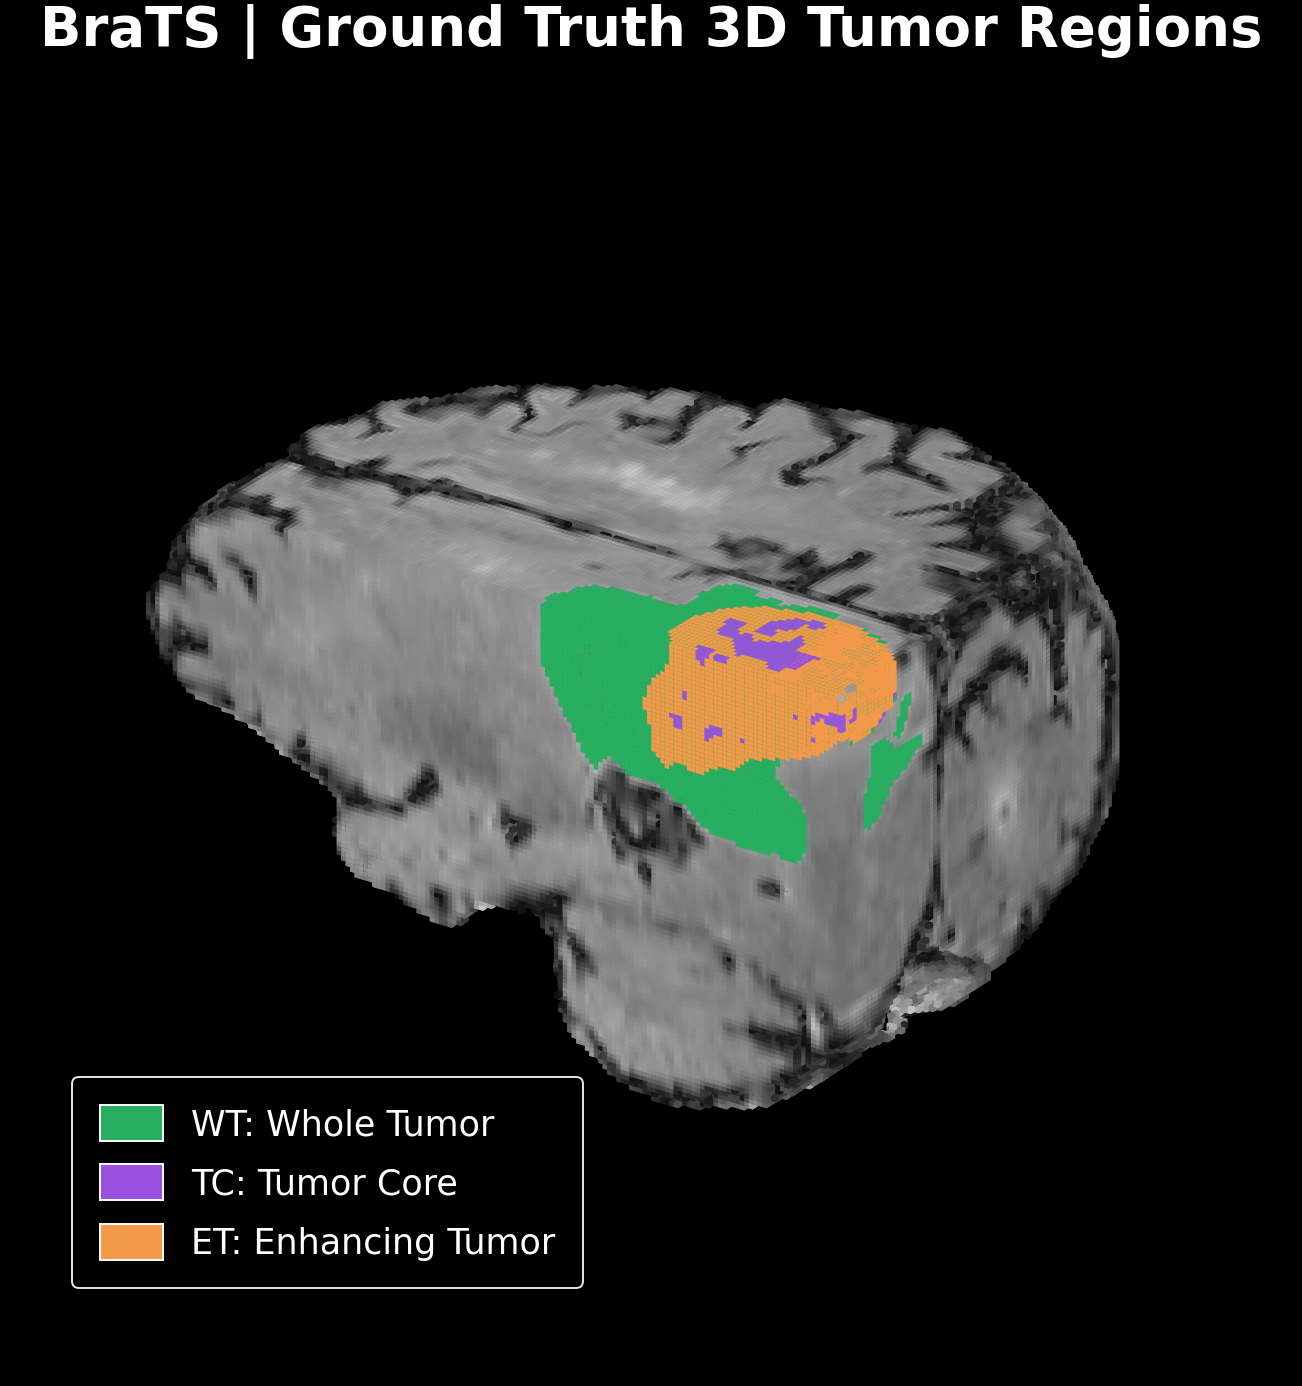

In [7]:
viz_ground_truth = create_viz()
set_gt_legend(viz_ground_truth)
preview_ground_truth = preview_frame("01_ground_truth_preview.png", viz_ground_truth, seg, GT_TITLE)

## Preview: Centralized S32

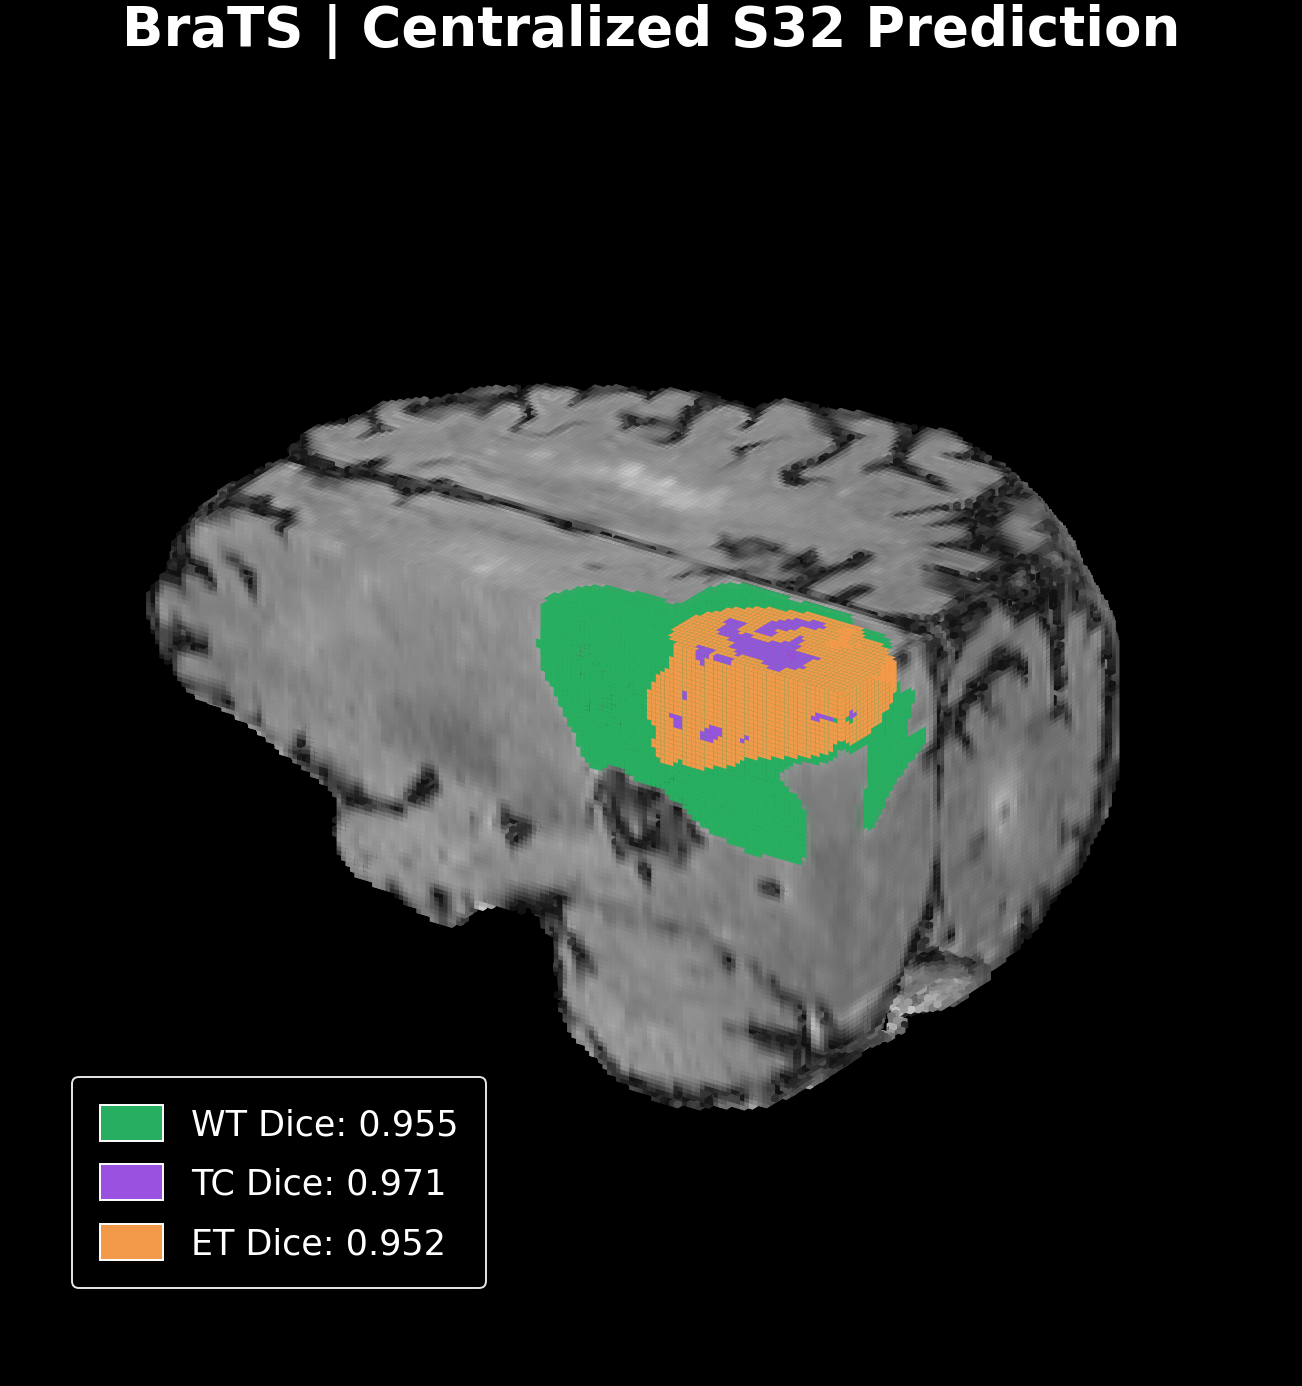

In [8]:
viz_centralized = create_viz()
set_pred_legend_with_dice(viz_centralized, 'Centralized S32')
preview_centralized = preview_frame(
    "02_centralized_s32_preview.png",
    viz_centralized,
    pred_centralized_thr,
    MODEL_CONFIGS["Centralized S32"]["title"]
)

## Preview: FedAvg S32

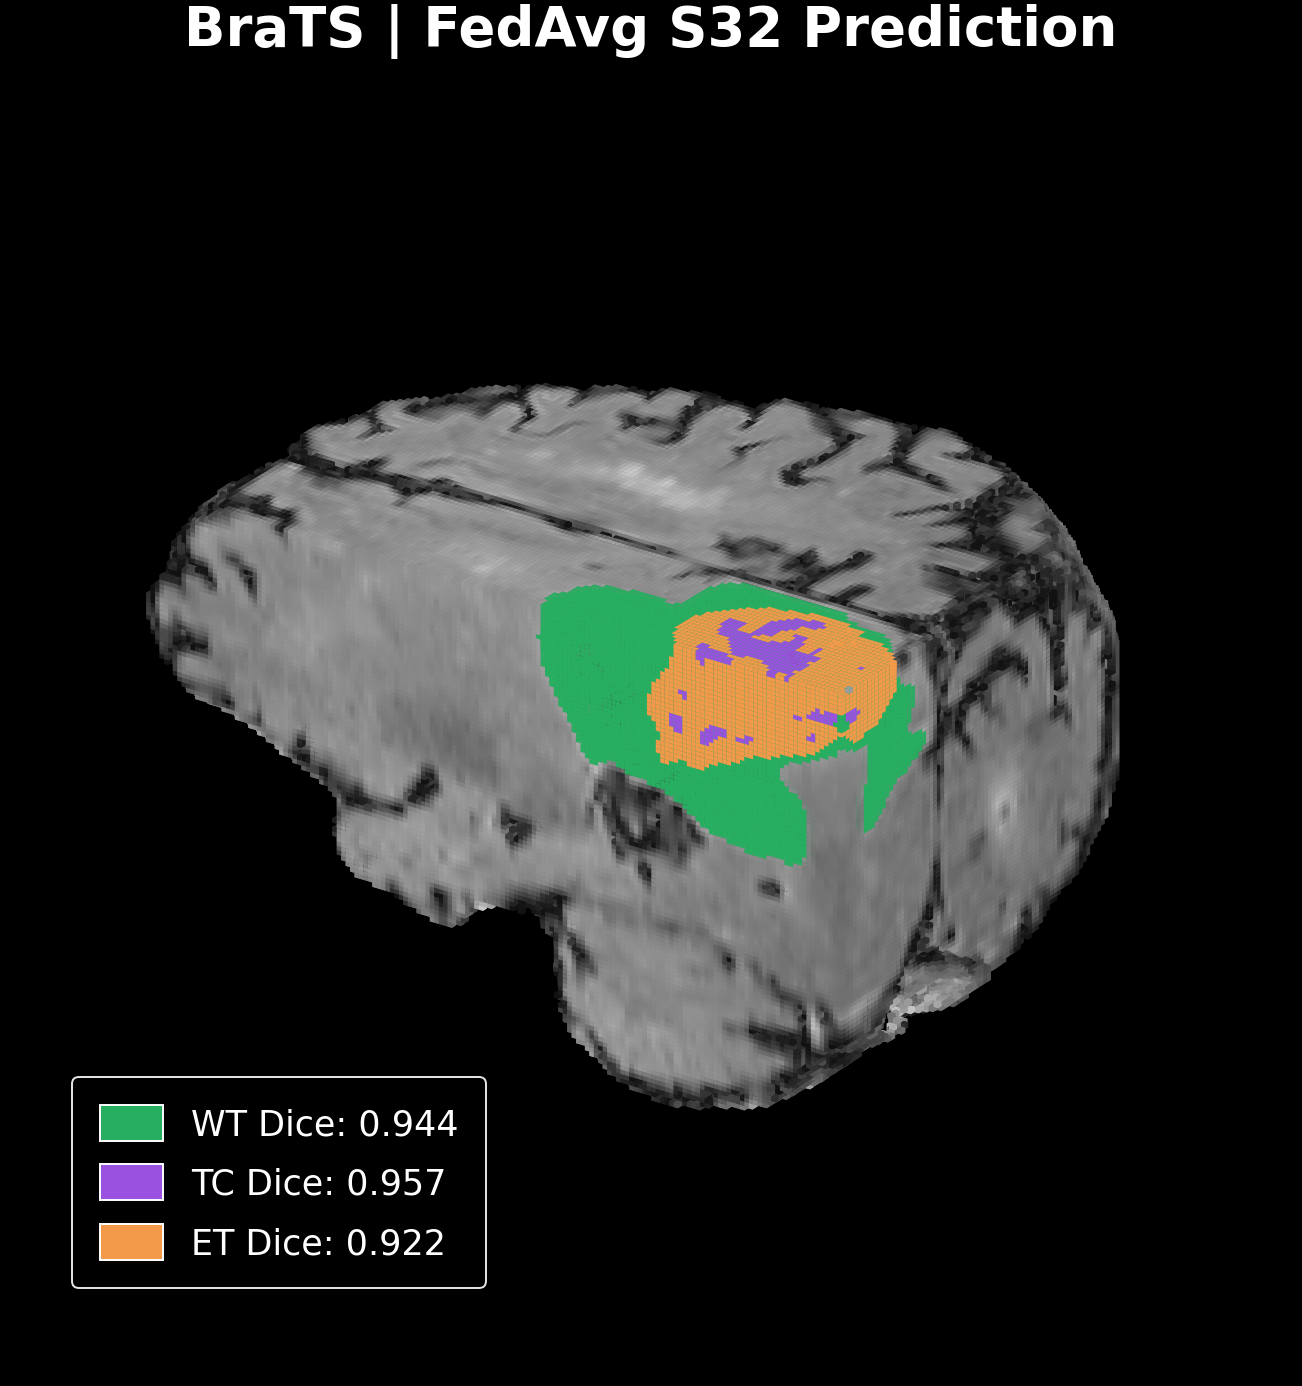

In [9]:
viz_fedavg = create_viz()
set_pred_legend_with_dice(viz_fedavg, 'FedAvg S32')
preview_fedavg = preview_frame(
    "03_fedavg_s32_preview.png",
    viz_fedavg,
    pred_fedavg_thr,
    MODEL_CONFIGS["FedAvg S32"]["title"]
)

## Preview: FedProx S32

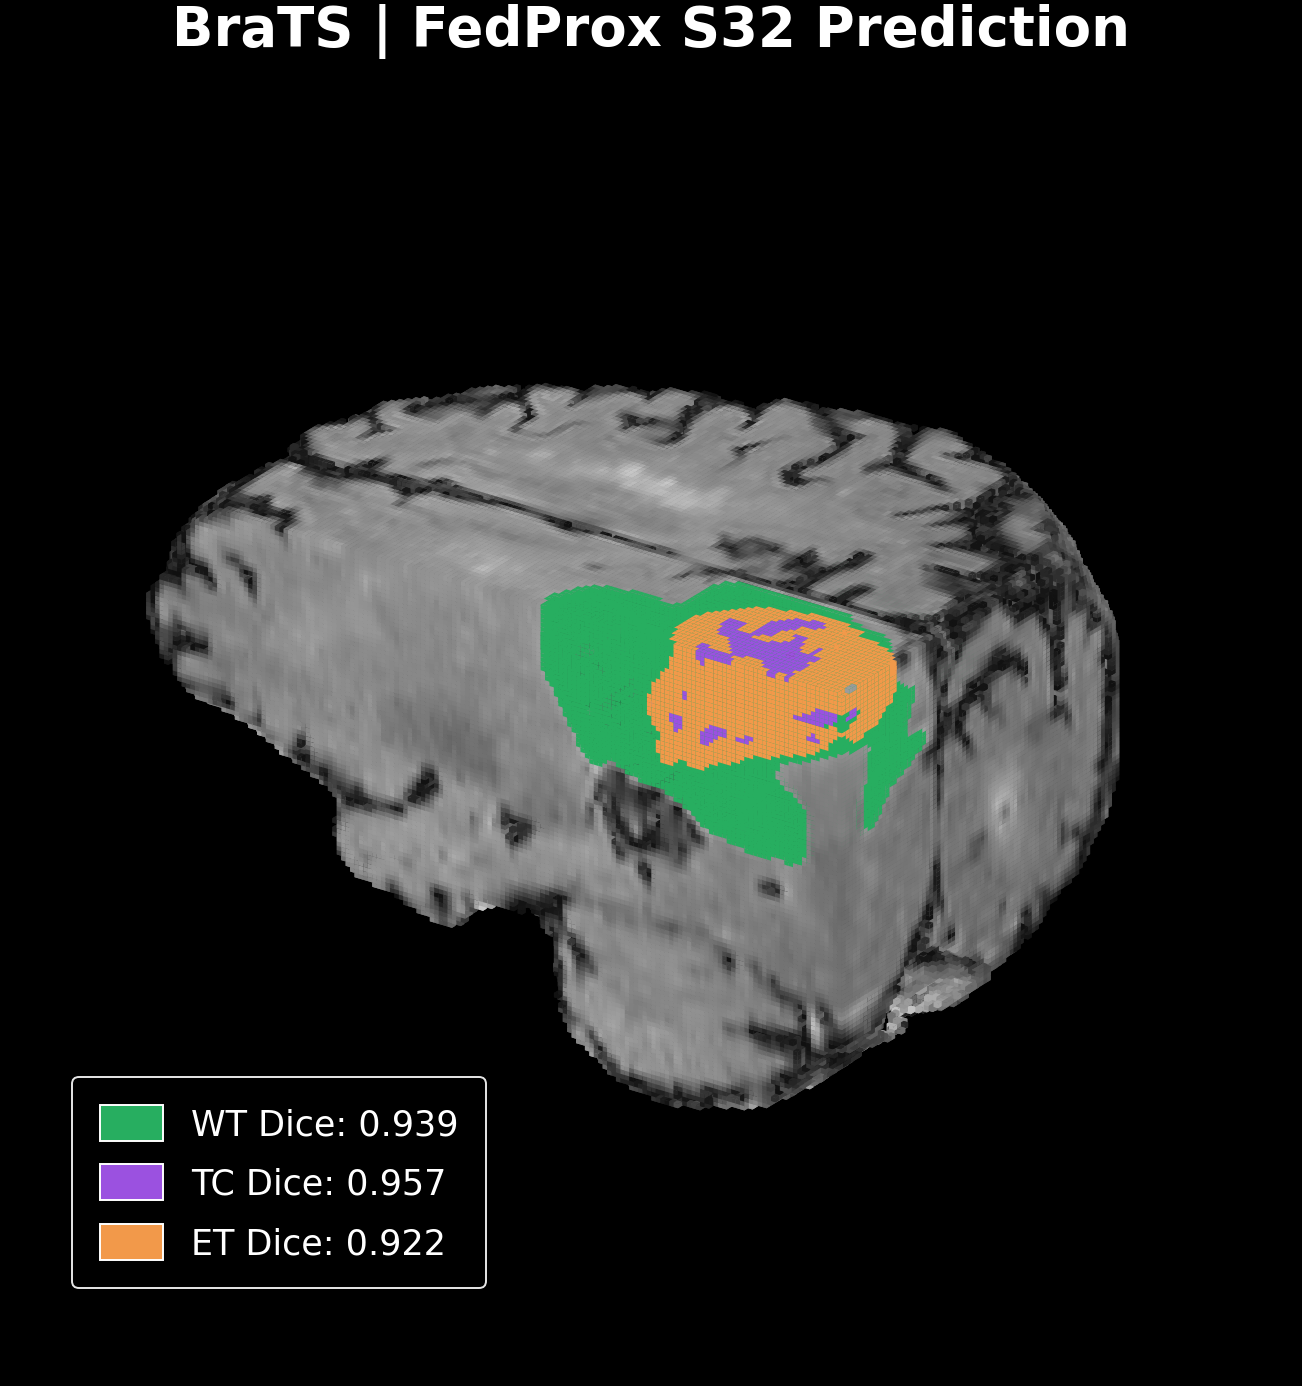

In [10]:
viz_fedprox = create_viz()
set_pred_legend_with_dice(viz_fedprox, 'FedProx S32')
preview_fedprox = preview_frame(
    "04_fedprox_s32_preview.png",
    viz_fedprox,
    pred_fedprox_thr,
    MODEL_CONFIGS["FedProx S32"]["title"]
)

## Optional rotation-angle checks

In [ ]:
CHECK_ROTATION_ANGLES = False
if CHECK_ROTATION_ANGLES:
    for angle in (0, 50, 60, 70, 90, 135, 180, 225, 270, 315):
        preview_frame(f"angle_{angle:03d}.png", viz_ground_truth, seg, GT_TITLE, angle=angle)

## Rotation video: Ground truth

In [ ]:
video_ground_truth = render_video_folder(
    "01_ground_truth", "ground_truth.mp4", viz_ground_truth, seg, GT_TITLE,
)

## Rotation video: Centralized S32

In [ ]:
video_centralized = render_video_folder(
    "02_centralized_s32", "centralized_s32.mp4", viz_centralized, pred_centralized_thr, MODEL_CONFIGS["Centralized S32"]["title"],
)

## Rotation video: FedAvg S32

In [ ]:
video_fedavg = render_video_folder(
    "03_fedavg_s32", "fedavg_s32.mp4", viz_fedavg, pred_fedavg_thr, MODEL_CONFIGS["FedAvg S32"]["title"],
)

## Rotation video: FedProx S32

In [ ]:
video_fedprox = render_video_folder(
    "04_fedprox_s32", "fedprox_s32.mp4", viz_fedprox, pred_fedprox_thr, MODEL_CONFIGS["FedProx S32"]["title"],
)

## Re-encode existing frames without rendering

Frame order is explicit. This changes only the viewing copy; the saved PNGs are retained.

In [ ]:
REENCODE_EXISTING = False
if REENCODE_EXISTING:
    frames_dir = case_output_root / "01_ground_truth" / "frames"
    rebuilt = frames_to_mp4(sorted(frames_dir.glob("frame_*.png")),
                            frames_dir.parent / "ground_truth_reencoded.mp4", fps=FPS)
    display(Video(rebuilt, embed=True, html_attributes="controls loop"))